In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])

import os, random, gc, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint
import torchvision.transforms as T
from torchvision.models import resnext50_32x4d, ResNeXt50_32X4D_Weights
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, f1_score)
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings("ignore")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 55)
print("ENVIRONMENT REPORT")
print("=" * 55)
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    free, total = torch.cuda.mem_get_info(0)
    print(f"GPU     : {props.name}")
    print(f"VRAM    : {total/1e9:.1f} GB total | {free/1e9:.2f} GB free")
print("Cell 1 complete ✓")


ENVIRONMENT REPORT
PyTorch : 2.9.0+cu126
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB total | 15.53 GB free
Cell 1 complete ✓


In [3]:
import os

# ── Hardcoded correct paths ───────────────────────────────────────────────────
BASE   = Path("/kaggle/input/datasets/omkarphadtare30/deepguard-dataset")
CSVDIR = BASE / "csvs"

# ── Verify all 3 CSVs exist ───────────────────────────────────────────────────
print("=" * 55)
print("DATASET PATH SCAN")
print("=" * 55)
for f in ["fixed_train.csv", "fixed_val.csv", "fixed_test.csv"]:
    p = CSVDIR / f
    status = "✓" if p.exists() else "✗ NOT FOUND"
    print(f"  {status}  {p}")

assert (CSVDIR / "fixed_train.csv").exists(), "fixed_train.csv not found — check dataset is attached"
assert (CSVDIR / "fixed_val.csv").exists(),   "fixed_val.csv not found"
assert (CSVDIR / "fixed_test.csv").exists(),  "fixed_test.csv not found"
print("All CSVs confirmed ✓")

# ── Config ────────────────────────────────────────────────────────────────────
CFG = dict(
    lstm_hidden     = 1024,
    lstm_layers     = 1,
    dropout         = 0.4,
    num_classes     = 2,
    img_size        = 224,
    img_mean        = (0.485, 0.456, 0.406),
    img_std         = (0.229, 0.224, 0.225),
    num_workers     = 4,
    phase1_epochs   = 8,
    phase1_lr       = 5e-4,
    phase1_patience = 5,
    phase1_batch    = 16,
    phase2_epochs   = 40,
    phase2_lr_bb    = 5e-6,
    phase2_lr_head  = 5e-5,
    phase2_patience = 12,
    phase2_batch    = 4,
    accum_steps     = 4,
    weight_decay    = 2e-4,
    label_smoothing = 0.05,
    grad_clip       = 1.0,
    mix_prob        = 0.4,
    mixup_alpha     = 0.2,
    cutmix_alpha    = 0.4,
    fake_boost      = 1.15,
    rlrop_factor    = 0.5,
    rlrop_patience  = 3,
    rlrop_min_lr    = 1e-8,
    time_budget_sec = 11.67 * 3600,
    model_path      = "/kaggle/working/best_resnext_bilstm.pth",
)

# ── Load CSVs ─────────────────────────────────────────────────────────────────
train_df = pd.read_csv(CSVDIR / "fixed_train.csv")
val_df   = pd.read_csv(CSVDIR / "fixed_val.csv")
test_df  = pd.read_csv(CSVDIR / "fixed_test.csv")

print(f"\nCSV Columns found : {list(train_df.columns)}")
PATH_COL  = train_df.columns[0]   # auto-detect first column as path col
LABEL_COL = "label"
print(f"Path column  : {PATH_COL}")
print(f"Label column : {LABEL_COL}")

# ── Spot-check 10 paths ───────────────────────────────────────────────────────
sample = train_df.sample(10, random_state=42)
broken = [row[PATH_COL] for _, row in sample.iterrows() if not os.path.exists(row[PATH_COL])]
print(f"\nPath check : {len(broken)} broken out of 10")
if broken:
    for b in broken[:3]:
        print(f"  BROKEN: {b}")
else:
    print("All 10 paths valid ✓")

# ── Class weights with fake boost ─────────────────────────────────────────────
counts = train_df[LABEL_COL].value_counts().sort_index().values
class_weights = torch.tensor([1.0 / c for c in counts], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 2
class_weights[1] *= CFG["fake_boost"]
class_weights = class_weights / class_weights.sum() * 2
class_weights = class_weights.to(DEVICE)

torch.backends.cudnn.benchmark = True

print("\n" + "=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print(f"{'Split':8} {'Total':8} {'Real':8} {'Fake':8}")
print("-" * 36)
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    r = (df[LABEL_COL] == 0).sum()
    f = (df[LABEL_COL] == 1).sum()
    print(f"{name:8} {len(df):8} {r:8} {f:8}")
print(f"\nClass weights  Real: {class_weights[0]:.4f}  Fake: {class_weights[1]:.4f}")
print("Cell 2 complete ✓")


DATASET PATH SCAN
  ✓  /kaggle/input/datasets/omkarphadtare30/deepguard-dataset/csvs/fixed_train.csv
  ✓  /kaggle/input/datasets/omkarphadtare30/deepguard-dataset/csvs/fixed_val.csv
  ✓  /kaggle/input/datasets/omkarphadtare30/deepguard-dataset/csvs/fixed_test.csv
All CSVs confirmed ✓

CSV Columns found : ['imagepath', 'label', 'split']
Path column  : imagepath
Label column : label

Path check : 0 broken out of 10
All 10 paths valid ✓

DATASET SUMMARY
Split    Total    Real     Fake    
------------------------------------
train      239828   119914   119914
val         32374    16187    16187
test        15982     7991     7991

Class weights  Real: 0.9302  Fake: 1.0698
Cell 2 complete ✓


In [4]:
S    = CFG["img_size"]        # 224
MEAN = CFG["img_mean"]        # (0.485, 0.456, 0.406)
STD  = CFG["img_std"]         # (0.229, 0.224, 0.225)

# ── Phase 1 transform — minimal, backbone frozen ──────────────────────────────
phase1_transform = T.Compose([
    T.Resize((S, S)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

# ── Phase 2 transform — strong aug, full fine-tune ────────────────────────────
phase2_transform = T.Compose([
    T.Resize((S + 24, S + 24)),
    T.RandomCrop(S),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.07),
    T.RandomRotation(degrees=12),
    T.RandomGrayscale(p=0.05),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.15, scale=(0.02, 0.10)),
])

# ── Val / Test transform — clean, deterministic ───────────────────────────────
val_transform = T.Compose([
    T.Resize((S, S)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

print(f"Phase 1 steps : {len(phase1_transform.transforms)}")
print(f"Phase 2 steps : {len(phase2_transform.transforms)}")
print(f"Val/Test steps: {len(val_transform.transforms)}")

# ── Verify transforms on a real image ────────────────────────────────────────
sample_path = train_df[PATH_COL].iloc[0]
sample_img  = Image.open(sample_path).convert("RGB")
t1 = phase1_transform(sample_img)
t2 = phase2_transform(sample_img)
tv = val_transform(sample_img)
print(f"\nSample image size : {sample_img.size}")
print(f"Phase 1 output    : {tuple(t1.shape)}  min={t1.min():.3f} max={t1.max():.3f}")
print(f"Phase 2 output    : {tuple(t2.shape)}  min={t2.min():.3f} max={t2.max():.3f}")
print(f"Val output        : {tuple(tv.shape)}  min={tv.min():.3f} max={tv.max():.3f}")

# ── Dataset ───────────────────────────────────────────────────────────────────
class DeepfakeDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = torch.tensor(row[LABEL_COL], dtype=torch.long)
        try:
            img = Image.open(row[PATH_COL]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (S, S), 0)
        if self.transform:
            img = self.transform(img)
        return img, label

# ── DataLoader factory ────────────────────────────────────────────────────────
def make_loaders(train_transform, batch_size=None):
    bs = batch_size or CFG["phase1_batch"]
    kw = dict(num_workers=CFG["num_workers"], pin_memory=True,
              prefetch_factor=2, persistent_workers=True)
    train_ds = DeepfakeDataset(train_df, train_transform)
    val_ds   = DeepfakeDataset(val_df,   val_transform)
    test_ds  = DeepfakeDataset(test_df,  val_transform)
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,
                              drop_last=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False,
                              drop_last=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False,
                              drop_last=False, **kw)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(phase1_transform)

# ── Verification ──────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("DATALOADER VERIFICATION")
print("=" * 55)
print(f"Train : {len(train_loader):,} batches | {len(train_loader.dataset):,} images")
print(f"Val   : {len(val_loader):,} batches   | {len(val_loader.dataset):,} images")
print(f"Test  : {len(test_loader):,} batches  | {len(test_loader.dataset):,} images")
print(f"Batch size : {CFG['phase1_batch']}  |  Eff. batch : {CFG['phase1_batch'] * CFG['accum_steps']}")

imgs, labels = next(iter(train_loader))
print(f"\nBatch shape   : {tuple(imgs.shape)}")
print(f"Labels sample : {labels[:8].tolist()}")
print(f"Image dtype   : {imgs.dtype}")
print(f"Image min/max : {imgs.min():.3f} / {imgs.max():.3f}")
n_real = (labels == 0).sum().item()
n_fake = (labels == 1).sum().item()
print(f"Batch balance : {n_real} real | {n_fake} fake (ideal {CFG['phase1_batch']//2}/{CFG['phase1_batch']//2})")
print("Cell 3 complete ✓")


Phase 1 steps : 4
Phase 2 steps : 11
Val/Test steps: 3

Sample image size : (256, 256)
Phase 1 output    : (3, 224, 224)  min=-2.101 max=0.862
Phase 2 output    : (3, 224, 224)  min=-2.118 max=1.598
Val output        : (3, 224, 224)  min=-2.101 max=0.862

DATALOADER VERIFICATION
Train : 14,989 batches | 239,828 images
Val   : 2,024 batches   | 32,374 images
Test  : 999 batches  | 15,982 images
Batch size : 16  |  Eff. batch : 64

Batch shape   : (16, 3, 224, 224)
Labels sample : [1, 1, 0, 1, 0, 0, 1, 1]
Image dtype   : torch.float32
Image min/max : -2.118 / 2.640
Batch balance : 7 real | 9 fake (ideal 8/8)
Cell 3 complete ✓


In [5]:
class ResNeXtBiLSTM(nn.Module):
    def __init__(self, lstm_hidden=1024, lstm_layers=1,
                 dropout=0.4, num_classes=2, bidirectional=True):
        super().__init__()
        backbone = resnext50_32x4d(weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1)
        # Split into named stages for per-stage gradient checkpointing
        self.stem    = nn.Sequential(backbone.conv1, backbone.bn1,
                                     backbone.relu, backbone.maxpool)
        self.layer1  = backbone.layer1
        self.layer2  = backbone.layer2
        self.layer3  = backbone.layer3
        self.layer4  = backbone.layer4
        self.avgpool = backbone.avgpool
        self.feat_dim = 2048

        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size  = self.feat_dim,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = dropout if lstm_layers > 1 else 0.0,
            bidirectional = bidirectional,
        )
        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)  # 1024*2 = 2048

        self.head = nn.Sequential(
            nn.LayerNorm(lstm_out_dim),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes),
        )

    def freeze_backbone(self):
        for stage in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            for p in stage.parameters():
                p.requires_grad = False
        print("Backbone FROZEN — training BiLSTM + head only")

    def unfreeze_backbone(self):
        for stage in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            for p in stage.parameters():
                p.requires_grad = True
        print("Backbone UNFROZEN — full fine-tuning enabled")

    def _backbone_checkpointed(self, x):
        x = checkpoint(self.stem,   x, use_reentrant=False)
        x = checkpoint(self.layer1, x, use_reentrant=False)
        x = checkpoint(self.layer2, x, use_reentrant=False)
        x = checkpoint(self.layer3, x, use_reentrant=False)
        x = checkpoint(self.layer4, x, use_reentrant=False)
        return self.avgpool(x)

    def _backbone_normal(self, x):
        x = self.stem(x);    x = self.layer1(x)
        x = self.layer2(x);  x = self.layer3(x)
        x = self.layer4(x)
        return self.avgpool(x)

    def forward(self, x):
        # Accepts (B, C, H, W) from frame-level dataset — wraps as T=1 sequence
        if x.dim() == 4:
            x = x.unsqueeze(1)              # (B, C, H, W) → (B, 1, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        backbone_trainable = any(p.requires_grad for p in self.layer1.parameters())
        if backbone_trainable:
            feats = self._backbone_checkpointed(x)
        else:
            with torch.no_grad():
                feats = self._backbone_normal(x)

        feats    = feats.view(B, T, self.feat_dim)   # (B, T, 2048)
        lstm_out, _ = self.lstm(feats)               # (B, T, lstm_out_dim)
        last_hidden  = lstm_out[:, -1, :]            # (B, lstm_out_dim)
        return self.head(last_hidden)


# ── Build model ───────────────────────────────────────────────────────────────
model = ResNeXtBiLSTM(
    lstm_hidden   = CFG["lstm_hidden"],
    lstm_layers   = CFG["lstm_layers"],
    dropout       = CFG["dropout"],
    num_classes   = CFG["num_classes"],
    bidirectional = True,
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters()) / 1e6
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
bb_params = sum(p.numel() for p in [*model.stem.parameters(),
                                     *model.layer1.parameters(),
                                     *model.layer2.parameters(),
                                     *model.layer3.parameters(),
                                     *model.layer4.parameters()]) / 1e6
head_params = (sum(p.numel() for p in model.lstm.parameters()) +
               sum(p.numel() for p in model.head.parameters())) / 1e6

print("=" * 55)
print("MODEL SUMMARY")
print("=" * 55)
print(f"Backbone      : ResNeXt50-32x4d (ImageNet pretrained)")
print(f"BiLSTM        : hidden={CFG['lstm_hidden']} × 2 = {CFG['lstm_hidden']*2}  (bidirectional)")
print(f"Total params  : {total:.2f}M")
print(f"Backbone      : {bb_params:.2f}M")
print(f"BiLSTM + Head : {head_params:.2f}M")
print(f"Trainable now : {trainable:.2f}M  (all, before freeze)")

print("\nHEAD ARCHITECTURE")
for i, layer in enumerate(model.head):
    print(f"  {i}  {layer}")

# ── Dry-run forward pass ──────────────────────────────────────────────────────
print("\nDRY-RUN FORWARD PASS")
model.eval()
with torch.no_grad():
    # Test with (B, C, H, W) — exactly what DataLoader sends
    dummy = torch.randn(4, 3, S, S, device=DEVICE)
    out   = model(dummy)
    probs = F.softmax(out, dim=1)
    print(f"Input  : {tuple(dummy.shape)}  →  auto-wrapped to (4, 1, 3, 224, 224)")
    print(f"Output : {tuple(out.shape)}  (batch=4, classes=2)  ✓")
    print(f"Probs  : {probs.cpu().numpy().round(3)}")
    print(f"Probs sum per sample: {probs.sum(dim=1).cpu().numpy().round(4)}  (must all be 1.0)")

free, total_mem = torch.cuda.mem_get_info(0)
print(f"\nGPU memory used  : {(total_mem - free)/1e9:.2f} GB")
print(f"GPU memory free  : {free/1e9:.2f} GB")
model.train()
print("Cell 4 complete ✓")


Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 215MB/s] 


MODEL SUMMARY
Backbone      : ResNeXt50-32x4d (ImageNet pretrained)
BiLSTM        : hidden=1024 × 2 = 2048  (bidirectional)
Total params  : 49.22M
Backbone      : 22.98M
BiLSTM + Head : 26.24M
Trainable now : 49.22M  (all, before freeze)

HEAD ARCHITECTURE
  0  LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
  1  Dropout(p=0.4, inplace=False)
  2  Linear(in_features=2048, out_features=512, bias=True)
  3  GELU(approximate='none')
  4  Dropout(p=0.2, inplace=False)
  5  Linear(in_features=512, out_features=2, bias=True)

DRY-RUN FORWARD PASS
Input  : (4, 3, 224, 224)  →  auto-wrapped to (4, 1, 3, 224, 224)
Output : (4, 2)  (batch=4, classes=2)  ✓
Probs  : [[0.566 0.434]
 [0.56  0.44 ]
 [0.568 0.432]
 [0.569 0.431]]
Probs sum per sample: [1. 1. 1. 1.]  (must all be 1.0)

GPU memory used  : 0.48 GB
GPU memory free  : 15.16 GB
Cell 4 complete ✓


In [11]:
class ResNeXtBiLSTM(nn.Module):
    def __init__(self, lstm_hidden=1024, lstm_layers=1,
                 dropout=0.4, num_classes=2, bidirectional=True):
        super().__init__()
        backbone = resnext50_32x4d(weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1)
        self.stem    = nn.Sequential(backbone.conv1, backbone.bn1,
                                     backbone.relu, backbone.maxpool)
        self.layer1  = backbone.layer1
        self.layer2  = backbone.layer2
        self.layer3  = backbone.layer3
        self.layer4  = backbone.layer4
        self.avgpool = backbone.avgpool
        self.feat_dim = 2048

        self.lstm = nn.LSTM(
            input_size    = self.feat_dim,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            dropout       = dropout if lstm_layers > 1 else 0.0,
            bidirectional = bidirectional,
        )
        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.LayerNorm(lstm_out_dim),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes),
        )

    def freeze_backbone(self):
        for stage in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            for p in stage.parameters():
                p.requires_grad = False
        print("Backbone FROZEN — training BiLSTM + head only")

    def unfreeze_backbone(self):
        for stage in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            for p in stage.parameters():
                p.requires_grad = True
        print("Backbone UNFROZEN — full fine-tuning enabled")

    def forward(self, x):
        # Accepts (B, C, H, W) — wraps as T=1 sequence
        if x.dim() == 4:
            x = x.unsqueeze(1)              # (B, 1, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        # Simple forward — no gradient checkpointing (14GB VRAM is enough)
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        feats = self.avgpool(x)

        feats    = feats.view(B, T, self.feat_dim)      # (B, T, 2048)
        lstm_out, _ = self.lstm(feats)                  # (B, T, 2048)
        last_hidden  = lstm_out[:, -1, :]               # (B, 2048)
        return self.head(last_hidden)


# ── Rebuild model and load Phase 1 best weights ───────────────────────────────
model = ResNeXtBiLSTM(
    lstm_hidden   = CFG["lstm_hidden"],
    lstm_layers   = CFG["lstm_layers"],
    dropout       = CFG["dropout"],
    num_classes   = CFG["num_classes"],
    bidirectional = True,
).to(DEVICE)

# Load Phase 1 best checkpoint back in
model.load_state_dict(torch.load(CFG["model_path"], map_location=DEVICE, weights_only=True))

total = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model rebuilt — no gradient checkpointing ✓")
print(f"Total params : {total:.2f}M")

# Dry-run to confirm no errors
model.eval()
with torch.no_grad():
    dummy = torch.randn(4, 3, S, S, device=DEVICE)
    out   = model(dummy)
    print(f"Dry-run : {tuple(dummy.shape)} → {tuple(out.shape)}  ✓")

free, _ = torch.cuda.mem_get_info(0)
print(f"GPU free : {free/1e9:.2f} GB")
print("Cell 4 (fixed) complete ✓")


Model rebuilt — no gradient checkpointing ✓
Total params : 49.22M
Dry-run : (4, 3, 224, 224) → (4, 2)  ✓
GPU free : 13.82 GB
Cell 4 (fixed) complete ✓


In [6]:
# ── MixUp ─────────────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

# ── CutMix ────────────────────────────────────────────────────────────────────
def rand_bbox(size, lam):
    W, H   = size[2], size[3]
    cut_r  = np.sqrt(1.0 - lam)
    cw, ch = int(W * cut_r), int(H * cut_r)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cw // 2, 0, W);  x2 = np.clip(cx + cw // 2, 0, W)
    y1 = np.clip(cy - ch // 2, 0, H);  y2 = np.clip(cy + ch // 2, 0, H)
    return x1, y1, x2, y2

def cutmix_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    mixed = x.clone()
    mixed[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1 - (x2 - x1) * (y2 - y1) / (x.size(-1) * x.size(-2))
    return mixed, y, y[idx], lam

def mixed_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)

# ── Quick sanity check ────────────────────────────────────────────────────────
imgs_test, labels_test = next(iter(train_loader))
imgs_test, labels_test = imgs_test.to(DEVICE), labels_test.to(DEVICE)
mx_imgs, ya, yb, lam_mx = mixup_data(imgs_test, labels_test, CFG["mixup_alpha"])
cm_imgs, ya2, yb2, lam_cm = cutmix_data(imgs_test, labels_test, CFG["cutmix_alpha"])
B = imgs_test.size(0)
crit_test   = nn.CrossEntropyLoss()
dummy_pred  = torch.randn(B, 2, device=DEVICE)
loss_test   = mixed_criterion(crit_test, dummy_pred, ya, yb, lam_mx)
print("=" * 50)
print("MIXUP / CUTMIX VERIFICATION")
print("=" * 50)
print(f"MixUp  lam={lam_mx:.4f}  shape={tuple(mx_imgs.shape)}")
print(f"CutMix lam={lam_cm:.4f}  shape={tuple(cm_imgs.shape)}")
print(f"mixed_criterion loss={loss_test.item():.4f}  ✓")
del imgs_test, labels_test, mx_imgs, cm_imgs, dummy_pred
torch.cuda.empty_cache()

# ── Training Loop ─────────────────────────────────────────────────────────────
ACCUM_STEPS = CFG["accum_steps"]   # 4  →  eff. batch = phase1_batch(16) * 4 = 64

def run_epoch(model, loader, criterion, optimizer, scaler,
              is_train=True, use_mix=False, accum_steps=1):
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_preds, all_labels = [], [], []
    if is_train:
        optimizer.zero_grad()

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for i, (imgs, labels) in enumerate(tqdm(
                loader, desc="Train" if is_train else "Val", leave=False)):
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            mixed, lam, ya, yb = False, 1.0, labels, labels
            if is_train and use_mix and random.random() < CFG["mix_prob"]:
                if random.random() < 0.5:
                    imgs, ya, yb, lam = mixup_data(imgs, labels, CFG["mixup_alpha"])
                else:
                    imgs, ya, yb, lam = cutmix_data(imgs, labels, CFG["cutmix_alpha"])
                mixed = True

            with autocast("cuda"):
                logits = model(imgs)
                loss   = (mixed_criterion(criterion, logits, ya, yb, lam)
                          if mixed else criterion(logits, labels))
                loss   = loss / accum_steps

            if is_train:
                scaler.scale(loss).backward()
                if (i + 1) % accum_steps == 0 or (i + 1) == len(loader):
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()

            probs = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            preds = logits.argmax(dim=1).detach().cpu().numpy()
            labs  = labels.detach().cpu().numpy()
            total_loss += loss.item() * accum_steps * labels.size(0)
            correct    += (preds == labs).sum()
            total      += labels.size(0)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labs)

    avg_loss = total_loss / total
    accuracy = correct / total
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, accuracy, auc, all_preds, all_labels

print("\nTraining loop defined ✓")
print(f"Accum steps : {ACCUM_STEPS}  →  effective batch = {CFG['phase1_batch'] * ACCUM_STEPS}")
print("Cell 5 complete ✓")


MIXUP / CUTMIX VERIFICATION
MixUp  lam=0.0094  shape=(16, 3, 224, 224)
CutMix lam=0.6314  shape=(16, 3, 224, 224)
mixed_criterion loss=1.1096  ✓

Training loop defined ✓
Accum steps : 4  →  effective batch = 64
Cell 5 complete ✓


In [7]:
TRAIN_START = time.time()

model.freeze_backbone()

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["phase1_lr"], weight_decay=CFG["weight_decay"],
)
scheduler_p1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_p1,
    max_lr           = CFG["phase1_lr"],
    steps_per_epoch  = len(train_loader),
    epochs           = CFG["phase1_epochs"],
    pct_start        = 0.3,
    anneal_strategy  = "cos",
)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CFG["label_smoothing"])
scaler_p1 = GradScaler("cuda")

history_p1  = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], val_auc=[])
best_val_acc = 0.0
patience_ctr = 0

print("=" * 60)
print(f"PHASE 1 — BiLSTM + Head only  |  {CFG['phase1_epochs']} epochs max  |  patience={CFG['phase1_patience']}")
print(f"Trainable : {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.3f}M")
print(f"Train batches : {len(train_loader):,}")
print(f"LR : {CFG['phase1_lr']}")
print("=" * 60)

for epoch in range(1, CFG["phase1_epochs"] + 1):
    elapsed = time.time() - TRAIN_START
    if elapsed > CFG["time_budget_sec"] * 0.20:
        print(f"⚠ Time threshold hit at P1 epoch {epoch} — moving to Phase 2")
        break

    tr_loss, tr_acc, tr_auc, _, _ = run_epoch(
        model, train_loader, criterion, optimizer_p1, scaler_p1,
        is_train=True, use_mix=False, accum_steps=ACCUM_STEPS)
    va_loss, va_acc, va_auc, _, _ = run_epoch(
        model, val_loader, criterion, optimizer_p1, scaler_p1,
        is_train=False)
    scheduler_p1.step()

    for k, v in zip(["train_loss","val_loss","train_acc","val_acc","val_auc"],
                    [tr_loss, va_loss, tr_acc, va_acc, va_auc]):
        history_p1[k].append(v)

    saved = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), CFG["model_path"])
        saved = " ← saved"
        patience_ctr = 0
    else:
        patience_ctr += 1

    print(f"P1 Ep {epoch:02d}/{CFG['phase1_epochs']:02d}  "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f}  "
          f"Val Loss {va_loss:.4f} Acc {va_acc:.4f} AUC {va_auc:.4f}{saved}")

    if patience_ctr >= CFG["phase1_patience"]:
        print(f"Early stopping Phase 1 at epoch {epoch}")
        break

print(f"\nPhase 1 complete ✓  Best Val Acc: {best_val_acc*100:.2f}%")
print("Cell 6 complete ✓")


Backbone FROZEN — training BiLSTM + head only
PHASE 1 — BiLSTM + Head only  |  8 epochs max  |  patience=5
Trainable : 26.236M
Train batches : 14,989
LR : 0.0005


P1 Ep 01/08  Train Loss 0.5698 Acc 0.7049  Val Loss 0.5244 Acc 0.7378 AUC 0.8343 ← saved


P1 Ep 02/08  Train Loss 0.5246 Acc 0.7474  Val Loss 0.5194 Acc 0.7394 AUC 0.8477 ← saved


P1 Ep 03/08  Train Loss 0.5076 Acc 0.7608  Val Loss 0.5108 Acc 0.7458 AUC 0.8547 ← saved


P1 Ep 04/08  Train Loss 0.4964 Acc 0.7698  Val Loss 0.4930 Acc 0.7641 AUC 0.8667 ← saved


P1 Ep 05/08  Train Loss 0.4867 Acc 0.7782  Val Loss 0.4861 Acc 0.7700 AUC 0.8715 ← saved


P1 Ep 06/08  Train Loss 0.4790 Acc 0.7828  Val Loss 0.4696 Acc 0.7851 AUC 0.8743 ← saved


P1 Ep 07/08  Train Loss 0.4727 Acc 0.7884  Val Loss 0.4781 Acc 0.7773 AUC 0.8772


P1 Ep 08/08  Train Loss 0.4648 Acc 0.7939  Val Loss 0.4605 Acc 0.7925 AUC 0.8808 ← saved

Phase 1 complete ✓  Best Val Acc: 79.25%
Cell 6 complete ✓


In [12]:
# ── Fix batch size for Phase 2 ────────────────────────────────────────────────
CFG["phase2_batch"] = 32   # sweet spot — 23 epochs possible in remaining time
ACCUM_STEPS         = 2    # eff. batch = 32 × 2 = 64

# Load best Phase 1 weights and unfreeze
model.load_state_dict(torch.load(CFG["model_path"], map_location=DEVICE, weights_only=True))
model.unfreeze_backbone()
gc.collect();  torch.cuda.empty_cache()

# Rebuild loaders with Phase 2 strong augmentation + batch=32
train_loader, val_loader, test_loader = make_loaders(
    phase2_transform, batch_size=CFG["phase2_batch"])

# Discriminative LRs — backbone gets 10× smaller LR than head
backbone_params = (list(model.stem.parameters())   +
                   list(model.layer1.parameters())  +
                   list(model.layer2.parameters())  +
                   list(model.layer3.parameters())  +
                   list(model.layer4.parameters()))
head_params     = (list(model.lstm.parameters()) +
                   list(model.head.parameters()))

optimizer_p2 = torch.optim.AdamW([
    {"params": backbone_params, "lr": CFG["phase2_lr_bb"]},
    {"params": head_params,     "lr": CFG["phase2_lr_head"]},
], weight_decay=CFG["weight_decay"])

scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode="max", factor=CFG["rlrop_factor"],
    patience=CFG["rlrop_patience"], min_lr=CFG["rlrop_min_lr"],
)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CFG["label_smoothing"])
scaler_p2 = GradScaler("cuda")

history_p2      = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], val_auc=[])
best_val_acc_p2 = 0.0
patience_ctr    = 0

free, total_mem = torch.cuda.mem_get_info(0)
print(f"GPU free before Phase 2: {free/1e9:.2f} GB")
print("=" * 65)
print(f"PHASE 2 — Full fine-tune  |  {CFG['phase2_epochs']} epochs max  |  patience={CFG['phase2_patience']}")
print(f"Backbone LR : {CFG['phase2_lr_bb']}   Head LR : {CFG['phase2_lr_head']}")
print(f"Batch : {CFG['phase2_batch']}  Accum : {ACCUM_STEPS}  → Eff. batch : {CFG['phase2_batch'] * ACCUM_STEPS}")
print(f"Train batches : {len(train_loader):,}")
print("=" * 65)

for epoch in range(1, CFG["phase2_epochs"] + 1):
    elapsed   = time.time() - TRAIN_START
    remaining = CFG["time_budget_sec"] - elapsed
    print(f"  [Elapsed {elapsed/3600:.1f}h | Remaining {remaining/3600:.1f}h]")

    if remaining < 3600:
        print("⚠ Less than 1 hour remaining — stopping to preserve model.")
        break

    tr_loss, tr_acc, tr_auc, _, _ = run_epoch(
        model, train_loader, criterion, optimizer_p2, scaler_p2,
        is_train=True, use_mix=True, accum_steps=ACCUM_STEPS)
    va_loss, va_acc, va_auc, _, _ = run_epoch(
        model, val_loader, criterion, optimizer_p2, scaler_p2,
        is_train=False)
    scheduler_p2.step(va_acc)

    for k, v in zip(["train_loss","val_loss","train_acc","val_acc","val_auc"],
                    [tr_loss, va_loss, tr_acc, va_acc, va_auc]):
        history_p2[k].append(v)

    bb_lr = optimizer_p2.param_groups[0]["lr"]
    hd_lr = optimizer_p2.param_groups[1]["lr"]
    saved = ""
    if va_acc > best_val_acc_p2:
        best_val_acc_p2 = va_acc
        torch.save(model.state_dict(), CFG["model_path"])
        saved = " ← saved"
        patience_ctr = 0
    else:
        patience_ctr += 1

    print(f"P2 Ep {epoch:02d}/{CFG['phase2_epochs']:02d}  "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f}  "
          f"Val Loss {va_loss:.4f} Acc {va_acc:.4f} AUC {va_auc:.4f}  "
          f"LR bb={bb_lr:.2e} hd={hd_lr:.2e}{saved}")

    if patience_ctr >= CFG["phase2_patience"]:
        print(f"Early stopping Phase 2 at epoch {epoch}")
        break

print(f"\nPhase 2 complete ✓  Best Val Acc: {best_val_acc_p2*100:.2f}%")
print("Cell 7 complete ✓")


Backbone UNFROZEN — full fine-tuning enabled
GPU free before Phase 2: 14.31 GB
PHASE 2 — Full fine-tune  |  40 epochs max  |  patience=12
Backbone LR : 5e-06   Head LR : 5e-05
Batch : 32  Accum : 2  → Eff. batch : 64
Train batches : 7,494
  [Elapsed 1.7h | Remaining 10.0h]


P2 Ep 01/40  Train Loss 0.5144 Acc 0.7322  Val Loss 0.4183 Acc 0.8303 AUC 0.9128  LR bb=5.00e-06 hd=5.00e-05 ← saved
  [Elapsed 2.1h | Remaining 9.5h]


P2 Ep 02/40  Train Loss 0.4331 Acc 0.7879  Val Loss 0.3615 Acc 0.8639 AUC 0.9467  LR bb=5.00e-06 hd=5.00e-05 ← saved
  [Elapsed 2.6h | Remaining 9.1h]


P2 Ep 03/40  Train Loss 0.3988 Acc 0.8089  Val Loss 0.3452 Acc 0.8759 AUC 0.9599  LR bb=5.00e-06 hd=5.00e-05 ← saved
  [Elapsed 3.0h | Remaining 8.6h]


P2 Ep 04/40  Train Loss 0.3737 Acc 0.8256  Val Loss 0.3222 Acc 0.8898 AUC 0.9625  LR bb=5.00e-06 hd=5.00e-05 ← saved
  [Elapsed 3.5h | Remaining 8.2h]


...

P2 Ep 16/40  Train Loss 0.2660 Acc 0.8795  Val Loss 0.2648 Acc 0.9307 AUC 0.9818  LR bb=2.50e-06 hd=2.50e-05 ← saved
  [Elapsed 8.9h | Remaining 2.7h]


P2 Ep 17/40  Train Loss 0.2640 Acc 0.8841  Val Loss 0.2686 Acc 0.9299 AUC 0.9826  LR bb=2.50e-06 hd=2.50e-05
  [Elapsed 9.4h | Remaining 2.3h]


P2 Ep 18/40  Train Loss 0.2604 Acc 0.8827  Val Loss 0.2678 Acc 0.9307 AUC 0.9752  LR bb=2.50e-06 hd=2.50e-05
  [Elapsed 9.8h | Remaining 1.8h]


P2 Ep 19/40  Train Loss 0.2586 Acc 0.8854  Val Loss 0.2408 Acc 0.9419 AUC 0.9869  LR bb=2.50e-06 hd=2.50e-05 ← saved
  [Elapsed 10.3h | Remaining 1.4h]


P2 Ep 20/40  Train Loss 0.2596 Acc 0.8839  Val Loss 0.2643 Acc 0.9307 AUC 0.9822  LR bb=2.50e-06 hd=2.50e-05
  [Elapsed 10.7h | Remaining 0.9h]
⚠ Less than 1 hour remaining — stopping to preserve model.

Phase 2 complete ✓  Best Val Acc: 94.19%
Cell 7 complete ✓


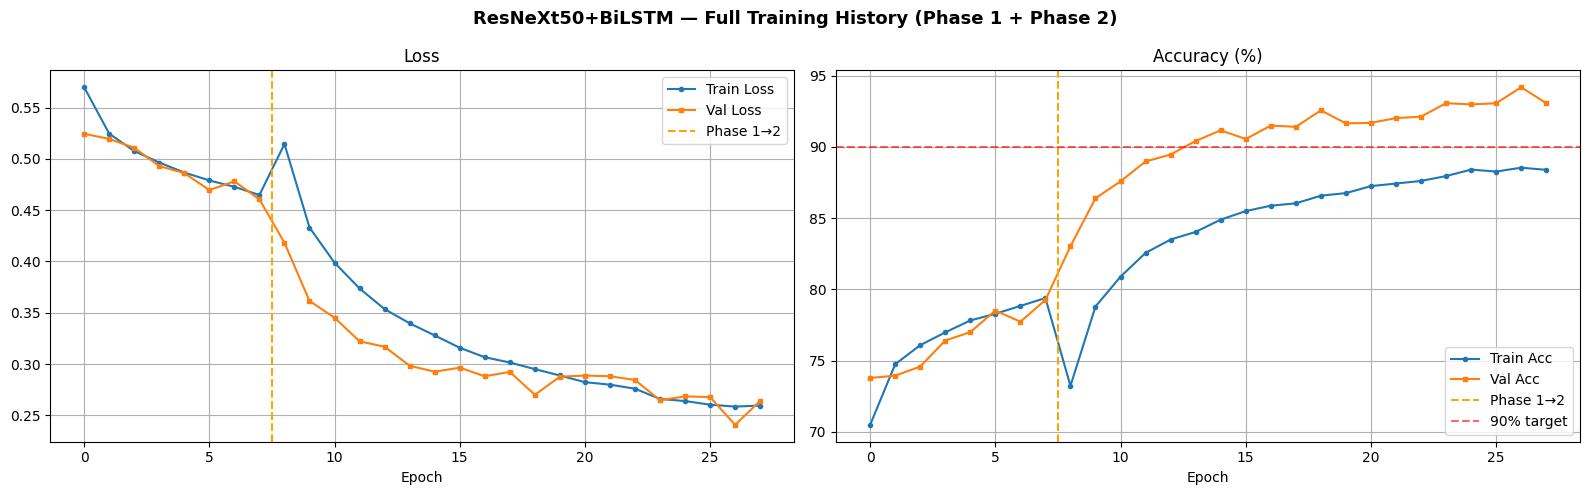

Best Val Acc : 94.19%
Saved resnext_bilstm_training_history.png
Cell 8 complete ✓


In [13]:
full_train_loss = history_p1["train_loss"] + history_p2["train_loss"]
full_val_loss   = history_p1["val_loss"]   + history_p2["val_loss"]
full_train_acc  = history_p1["train_acc"]  + history_p2["train_acc"]
full_val_acc    = history_p1["val_acc"]    + history_p2["val_acc"]
p1_end          = len(history_p1["train_loss"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("ResNeXt50+BiLSTM — Full Training History (Phase 1 + Phase 2)",
             fontsize=13, fontweight="bold")

axes[0].plot(full_train_loss, label="Train Loss", marker="o", ms=3)
axes[0].plot(full_val_loss,   label="Val Loss",   marker="s", ms=3)
axes[0].axvline(p1_end - 0.5, color="orange", linestyle="--", label="Phase 1→2")
axes[0].set_title("Loss");  axes[0].set_xlabel("Epoch")
axes[0].legend();           axes[0].grid(True)

axes[1].plot([a*100 for a in full_train_acc], label="Train Acc", marker="o", ms=3)
axes[1].plot([a*100 for a in full_val_acc],   label="Val Acc",   marker="s", ms=3)
axes[1].axvline(p1_end - 0.5, color="orange", linestyle="--", label="Phase 1→2")
axes[1].axhline(y=90, color="red", linestyle="--", alpha=0.6, label="90% target")
axes[1].set_title("Accuracy (%)");  axes[1].set_xlabel("Epoch")
axes[1].legend();                   axes[1].grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/resnext_bilstm_training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best Val Acc : {best_val_acc_p2*100:.2f}%")
print("Saved resnext_bilstm_training_history.png")
print("Cell 8 complete ✓")


Simple Test: 100%|██████████| 500/500 [00:54<00:00,  9.14it/s]


SIMPLE TEST RESULTS  ResNeXt50+BiLSTM  (No TTA)
Test Accuracy : 93.53%
Test AUC-ROC  : 0.9850
              precision    recall  f1-score   support

        Real     0.9166    0.9577    0.9367      7991
        Fake     0.9557    0.9129    0.9338      7991

    accuracy                         0.9353     15982
   macro avg     0.9362    0.9353    0.9353     15982
weighted avg     0.9362    0.9353    0.9353     15982



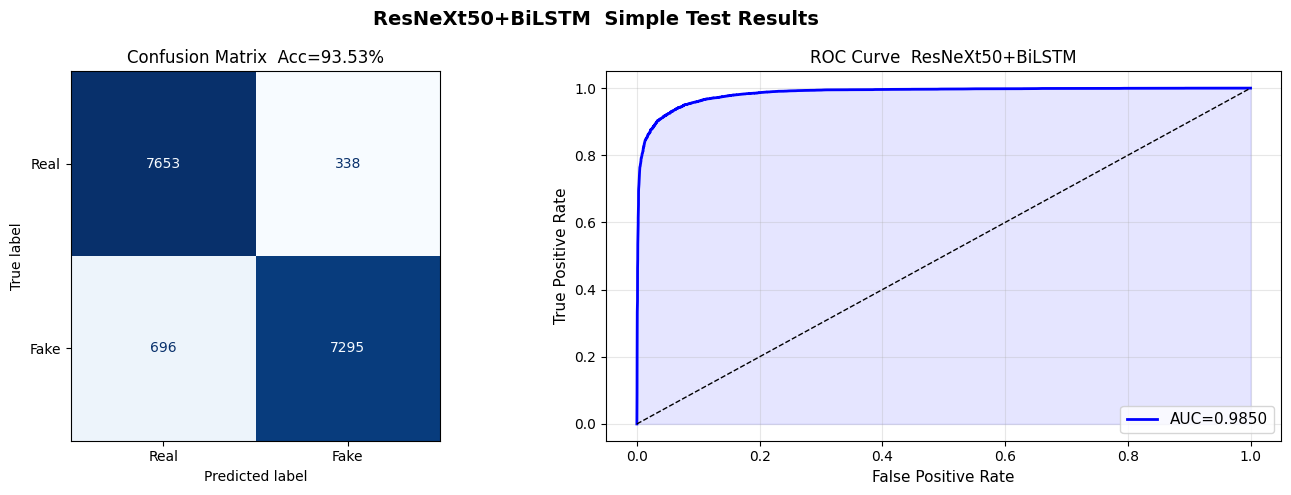

Saved resnext_bilstm_simpletest.png
Cell 9 complete ✓


In [14]:
# Load best checkpoint
model.load_state_dict(torch.load(CFG["model_path"], map_location=DEVICE, weights_only=True))
model.eval()

all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Simple Test"):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast("cuda"):
            logits = model(imgs)
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs);  all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
test_auc   = roc_auc_score(all_labels, all_probs)

print("=" * 60)
print("SIMPLE TEST RESULTS  ResNeXt50+BiLSTM  (No TTA)")
print("=" * 60)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test AUC-ROC  : {test_auc:.4f}")
print("=" * 60)
print(classification_report(all_labels, all_preds,
                             target_names=["Real","Fake"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNeXt50+BiLSTM  Simple Test Results", fontsize=14, fontweight="bold")

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["Real","Fake"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix  Acc={test_acc*100:.2f}%", fontsize=12)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, "b-", lw=2, label=f"AUC={test_auc:.4f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color="blue")
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].set_title("ROC Curve  ResNeXt50+BiLSTM", fontsize=12)
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/resnext_bilstm_simpletest.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved resnext_bilstm_simpletest.png")
print("Cell 9 complete ✓")


In [15]:
TTA_TRANSFORMS = [
    # View 1 — standard, no aug
    T.Compose([T.Resize((S, S)), T.ToTensor(), T.Normalize(MEAN, STD)]),
    # View 2 — horizontal flip
    T.Compose([T.Resize((S, S)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(MEAN, STD)]),
    # View 3 — center crop from slightly larger
    T.Compose([T.Resize((S+24, S+24)), T.CenterCrop(S),
               T.ToTensor(), T.Normalize(MEAN, STD)]),
    # View 4 — colour shift
    T.Compose([T.Resize((S, S)), T.ColorJitter(brightness=0.15, contrast=0.15),
               T.ToTensor(), T.Normalize(MEAN, STD)]),
    # View 5 — Gaussian blur
    T.Compose([T.Resize((S, S)), T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0)),
               T.ToTensor(), T.Normalize(MEAN, STD)]),
]

def tta_predict(model, df, tta_transforms, batch_size=None):
    """
    Runs inference with each TTA transform, averages softmax probabilities.
    Returns (final_preds, labels, fake_probs).
    """
    bs = batch_size or CFG["phase1_batch"]
    model.eval()
    all_avg_probs = None
    all_labels    = None

    for t_idx, transform in enumerate(tta_transforms):
        ds     = DeepfakeDataset(df, transform)
        loader = DataLoader(ds, batch_size=bs, shuffle=False,
                            num_workers=CFG["num_workers"], pin_memory=True,
                            persistent_workers=True)
        probs_list, labels_list = [], []
        with torch.no_grad():
            for imgs, labels in tqdm(loader,
                    desc=f"TTA {t_idx+1}/{len(tta_transforms)}", leave=False):
                imgs = imgs.to(DEVICE, non_blocking=True)
                with autocast("cuda"):
                    logits = model(imgs)
                probs = F.softmax(logits, dim=1).cpu().numpy()   # (B, 2)
                probs_list.append(probs)
                if t_idx == 0:
                    labels_list.extend(labels.numpy())

        probs_arr = np.concatenate(probs_list, axis=0)           # (N, 2)
        if all_avg_probs is None:
            all_avg_probs = probs_arr
            all_labels    = np.array(labels_list)
        else:
            all_avg_probs += probs_arr

    all_avg_probs /= len(tta_transforms)
    final_preds = np.argmax(all_avg_probs, axis=1)
    fake_probs  = all_avg_probs[:, 1]
    return final_preds, all_labels, fake_probs

print(f"TTA transforms : {len(TTA_TRANSFORMS)} views")
print("TTA function ready ✓")
print("Cell 10 complete ✓")


TTA transforms : 5 views
TTA function ready ✓
Cell 10 complete ✓


Running TTA on Validation set for threshold tuning...


Optimal threshold : 0.40  (both recalls ≥ 84%)
Best Val F1 macro : 0.9504

Running TTA on Test set...


FINAL TTA TEST RESULTS  ResNeXt50+BiLSTM
Threshold   : 0.40
Accuracy    : 94.01%
AUC-ROC     : 0.9875
Real Recall : 94.52%
Fake Recall : 93.51%
              precision    recall  f1-score   support

        Real     0.9357    0.9452    0.9404      7991
        Fake     0.9446    0.9351    0.9398      7991

    accuracy                         0.9401     15982
   macro avg     0.9402    0.9401    0.9401     15982
weighted avg     0.9402    0.9401    0.9401     15982



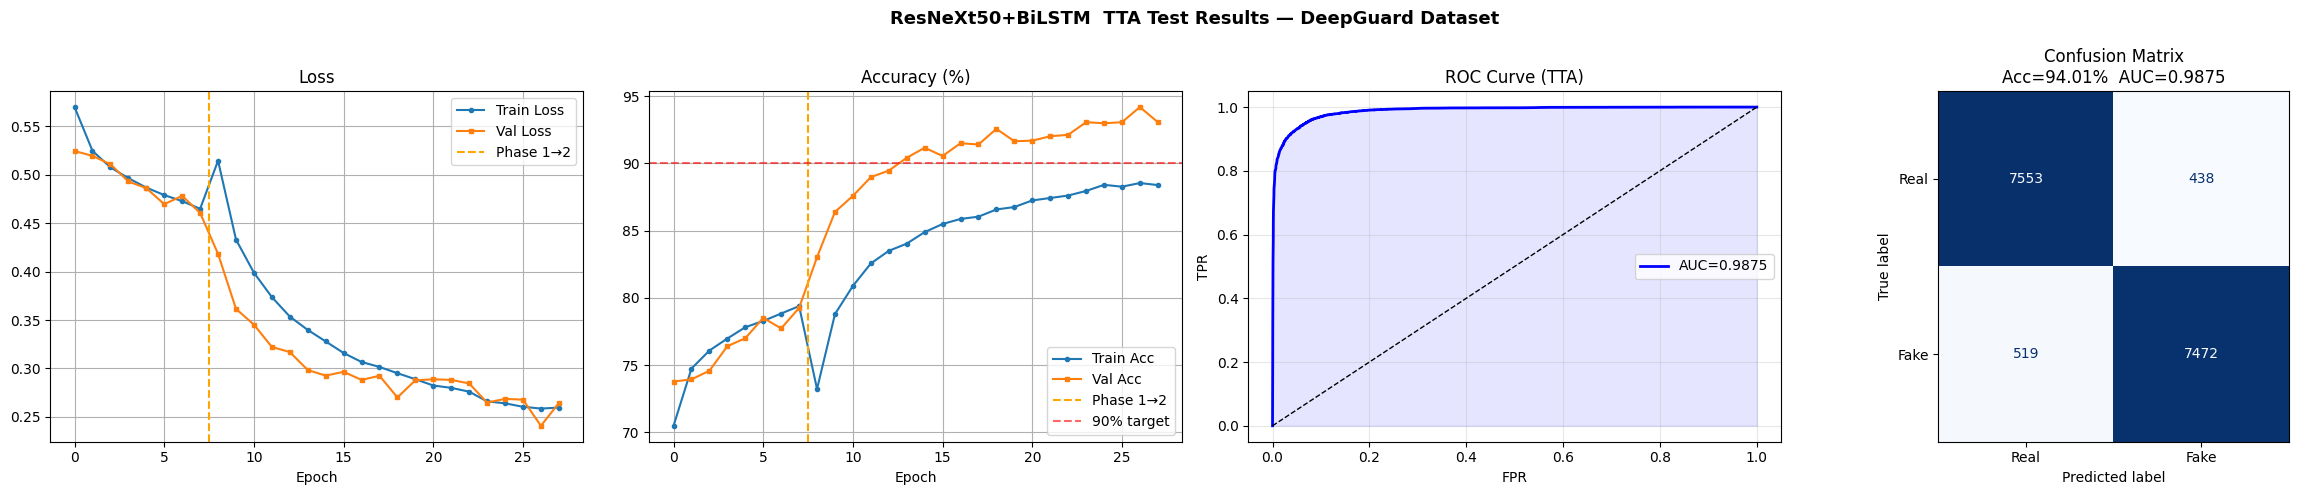


Saved: resnext_bilstm_ttaresults.png  |  resnext_bilstm_predictions.csv
Total training time : 10.91 hours
Cell 11 complete ✓


In [16]:
# ── Threshold tuning on validation set ────────────────────────────────────────
print("Running TTA on Validation set for threshold tuning...")
val_preds_tta, val_labels_tta, val_probs_tta = tta_predict(
    model, val_df, TTA_TRANSFORMS)

best_thresh, best_f1 = 0.5, 0.0
for thresh in np.arange(0.30, 0.71, 0.01):
    preds_t  = (val_probs_tta >= thresh).astype(int)
    real_rec = (preds_t[val_labels_tta == 0] == 0).mean()
    fake_rec = (preds_t[val_labels_tta == 1] == 1).mean()
    if real_rec >= 0.84 and fake_rec >= 0.84:
        f1_t = f1_score(val_labels_tta, preds_t, average="macro")
        if f1_t > best_f1:
            best_f1, best_thresh = f1_t, thresh

print(f"Optimal threshold : {best_thresh:.2f}  (both recalls ≥ 84%)")
print(f"Best Val F1 macro : {best_f1:.4f}")

# ── TTA on test set ────────────────────────────────────────────────────────────
print("\nRunning TTA on Test set...")
test_preds_tta, test_labels_tta, test_probs_tta = tta_predict(
    model, test_df, TTA_TRANSFORMS)

test_preds_tuned = (test_probs_tta >= best_thresh).astype(int)
test_acc_tta     = (test_preds_tuned == test_labels_tta).mean()
test_auc_tta     = roc_auc_score(test_labels_tta, test_probs_tta)
real_recall      = (test_preds_tuned[test_labels_tta == 0] == 0).mean()
fake_recall      = (test_preds_tuned[test_labels_tta == 1] == 1).mean()

print("=" * 65)
print("FINAL TTA TEST RESULTS  ResNeXt50+BiLSTM")
print("=" * 65)
print(f"Threshold   : {best_thresh:.2f}")
print(f"Accuracy    : {test_acc_tta*100:.2f}%")
print(f"AUC-ROC     : {test_auc_tta:.4f}")
print(f"Real Recall : {real_recall*100:.2f}%")
print(f"Fake Recall : {fake_recall*100:.2f}%")
print("=" * 65)
print(classification_report(test_labels_tta, test_preds_tuned,
                             target_names=["Real","Fake"], digits=4))

# ── Final 4-panel plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("ResNeXt50+BiLSTM  TTA Test Results — DeepGuard Dataset",
             fontsize=13, fontweight="bold")

axes[0].plot(full_train_loss, label="Train Loss", marker="o", ms=3)
axes[0].plot(full_val_loss,   label="Val Loss",   marker="s", ms=3)
axes[0].axvline(p1_end - 0.5, color="orange", linestyle="--", label="Phase 1→2")
axes[0].set_title("Loss");  axes[0].set_xlabel("Epoch")
axes[0].legend();           axes[0].grid(True)

axes[1].plot([a*100 for a in full_train_acc], label="Train Acc", marker="o", ms=3)
axes[1].plot([a*100 for a in full_val_acc],   label="Val Acc",   marker="s", ms=3)
axes[1].axvline(p1_end - 0.5, color="orange", linestyle="--", label="Phase 1→2")
axes[1].axhline(y=90, color="red", linestyle="--", alpha=0.6, label="90% target")
axes[1].set_title("Accuracy (%)");  axes[1].set_xlabel("Epoch")
axes[1].legend();                   axes[1].grid(True)

fpr, tpr, _ = roc_curve(test_labels_tta, test_probs_tta)
axes[2].plot(fpr, tpr, "b-", lw=2, label=f"AUC={test_auc_tta:.4f}")
axes[2].plot([0,1],[0,1], "k--", lw=1)
axes[2].fill_between(fpr, tpr, alpha=0.1, color="blue")
axes[2].set_xlabel("FPR");  axes[2].set_ylabel("TPR")
axes[2].set_title("ROC Curve (TTA)");  axes[2].legend();  axes[2].grid(True, alpha=0.3)

cm = confusion_matrix(test_labels_tta, test_preds_tuned)
ConfusionMatrixDisplay(cm, display_labels=["Real","Fake"]).plot(
    ax=axes[3], colorbar=False, cmap="Blues")
axes[3].set_title(f"Confusion Matrix\nAcc={test_acc_tta*100:.2f}%  AUC={test_auc_tta:.4f}")

plt.tight_layout()
plt.savefig("/kaggle/working/resnext_bilstm_ttaresults.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Save predictions CSV ───────────────────────────────────────────────────────
pd.DataFrame({
    "label":     test_labels_tta,
    "pred":      test_preds_tuned,
    "prob_fake": test_probs_tta,
}).to_csv("/kaggle/working/resnext_bilstm_predictions.csv", index=False)

total_time = time.time() - TRAIN_START
print(f"\nSaved: resnext_bilstm_ttaresults.png  |  resnext_bilstm_predictions.csv")
print(f"Total training time : {total_time/3600:.2f} hours")
print("Cell 11 complete ✓")
